# Enterprise People Cost & Workforce Expenditure Analytics
### Portfolio Project — End-to-End HR Cost & Budget Variance Monitoring System

**Author:** [Zafirah Aida Adista](https://www.linkedin.com/in/zafirah-aida-adista-162ab8379/)  
**Role:** Data Analytics

---

## 📌 Overview & Disclaimer

**Disclaimer:** Dataset yang digunakan dalam proyek ini merupakan **synthetic data (data simulasi)** yang dirancang untuk merepresentasikan karakteristik dan pola pengeluaran biaya tenaga kerja (*People Cost*) pada perusahaan manufaktur & FMCG berskala besar di Indonesia.

Pola data mencakup faktor musiman (*seasonality*) seperti alokasi Tunjangan Hari Raya (THR), fluktuasi operasional musiman, serta dinamika kompensasi antar divisi (termasuk IT, Sales, & Supply Chain). Proyek ini dibuat secara independen untuk mendemonstrasikan kemampuan pemrosesan data, pemantauan anggaran, dan penyusunan dashboard analitik HR.

---

### 🎯 Tujuan Analisis (Project Objectives)

1. **Peningkatan Visibilitas Biaya (*Cost Visibility*):**
   Mengonsolidasikan dan memetakan struktur *People Cost* dari berbagai komponen transaksi agar siap diakses secara transparan untuk pengambilan keputusan strategis.

2. **Analisis Variansi Anggaran (*Budget vs Actual Monitoring*):**
   Menganalisis tren pengeluaran bulanan serta mengidentifikasi potensi *variance* (selisih anggaran vs realisasi) di setiap divisi dan komponen biaya.

3. **Penyusunan Insight & Rekomendasi Efisiensi:**
   Menghasilkan *data-driven insights* serta rekomendasi konkret untuk mendukung pengendalian anggaran (*cost control*) yang lebih proaktif dan terukur.

4. **Kesiapan Model Data untuk Dashboard (*BI Integration*):**
   Membersihkan, memvalidasi, dan mengoperasionalkan struktur data agar dapat terhubung secara lancar (*automated periodic update*) ke *Business Intelligence tools* (Power BI/Tableau).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- Import color palette  ----
TEAL   = "#163F81"  
TEAL_L = "#215BAB"   
GOLD   = "#4E7FC7"   
CREAM  = "#F5F6F8"   
RED    = "#B3432B"   
GREY   = "#4D4D4D"   

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 10,
    "axes.edgecolor": GREY,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "figure.facecolor": "white",
})

def rp(x, pos=None):
    if x >= 1e9:
        return f"Rp{x/1e9:,.1f}M"
    if x >= 1e6:
        return f"Rp{x/1e6:,.0f}jt"
    return f"Rp{x:,.0f}"

pd.options.display.float_format = "{:,.0f}".format


## 1. Load & Data Quality Check

In [2]:
df = pd.read_csv("fmcg_workforce_cost_dataset.csv", parse_dates=["Date"])
print("Shape:", df.shape)
print("\nPeriode:", df['Date'].min().strftime('%b %Y'), "-", df['Date'].max().strftime('%b %Y'))
print("Jumlah Divisi:", df['Division'].nunique(), "| Jumlah Kategori Biaya:", df['Category'].nunique())
df.head()


Shape: (1728, 11)

Periode: Jan 2023 - Dec 2024
Jumlah Divisi: 8 | Jumlah Kategori Biaya: 9


,Date,Division,Category,Headcount,Budget_IDR,Actual_IDR,Year,Month,Month_Name,Variance_IDR,Variance_Pct
0,2023-01-01,Manufacturing & Produksi,Basic Salary,2208,"11,481,600,000","11,465,725,000",2023,1,Jan,"-15,875,000",-0
1,2023-01-01,Manufacturing & Produksi,Fixed Allowance,2208,"1,722,240,000","1,744,550,000",2023,1,Jan,"22,310,000",1
2,2023-01-01,Manufacturing & Produksi,Variable Allowance/Incentive,2208,"574,080,000","644,027,000",2023,1,Jan,"69,947,000",12
3,2023-01-01,Manufacturing & Produksi,Overtime,2208,"1,607,424,000","1,569,786,000",2023,1,Jan,"-37,638,000",-2
4,2023-01-01,Manufacturing & Produksi,BPJS (Kesehatan & Ketenagakerjaan),2208,"823,920,000","821,026,000",2023,1,Jan,"-2,894,000",-0


In [3]:
# Data quality check sederhana
qc = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "dtype": df.dtypes
})
print(qc[qc["missing_values"] > 0] if qc["missing_values"].sum() > 0 else "Tidak ada missing values.")
print("\nDuplicate rows:", df.duplicated(subset=["Date","Division","Category"]).sum())
print("Negative Actual/Budget check:", (df[["Actual_IDR","Budget_IDR"]] < 0).sum().sum())


Tidak ada missing values.

Duplicate rows: 0
Negative Actual/Budget check: 0


## 2. Executive Summary Metrics (Key Financial & Headcount Indicators)

Bagian ini menghitung indikator kinerja utama (KPI) untuk memberikan gambaran cepat terkait kesehatan anggaran biaya tenaga kerja.

* **Total Actual Spending:** Realisasi total pengeluaran *People Cost*.
* **Total Budget Allocation:** Alokasi total anggaran yang direncanakan.
* **Budget Variance (%):** Persentase penyimpangan realisasi terhadap anggaran (*cost efficiency indicator*).
* **Average Monthly Headcount:** Rata-rata jumlah tenaga kerja aktif per bulan.
* **Cost per Head per Month:** Rata-rata efisiensi pengeluaran *People Cost* per karyawan per bulan.

In [4]:
total_actual = df["Actual_IDR"].sum()
total_budget = df["Budget_IDR"].sum()
variance_pct = (total_actual - total_budget) / total_budget * 100
avg_headcount = df.groupby("Date")["Headcount"].sum().mean()
cost_per_head_month = df.groupby("Date")["Actual_IDR"].sum() / df.groupby("Date")["Headcount"].sum()

print(f"Total People Cost (2023-2024)     : {rp(total_actual)}")
print(f"Total Budget (2023-2024)          : {rp(total_budget)}")
print(f"Overall Variance                  : {variance_pct:+.1f}%")
print(f"Rata-rata Total Headcount / bulan : {avg_headcount:,.0f} karyawan")
print(f"Rata-rata Cost per Headcount/bulan: {rp(cost_per_head_month.mean())}")


Total People Cost (2023-2024)     : Rp1,157.1M
Total Budget (2023-2024)          : Rp1,117.6M
Overall Variance                  : +3.5%
Rata-rata Total Headcount / bulan : 39,814 karyawan
Rata-rata Cost per Headcount/bulan: Rp1jt


## 3. Monthly People Cost Expenditure: Budget vs. Actual Trend Analysis

Analisis lini masa ini membandingkan akumulasi pengeluaran *People Cost* aktual (garis biru tua) terhadap alokasi anggaran bulanan (garis putus-putus) selama periode 2023–2024. Area yang diarsir biru muda mengindikasikan periode efisiensi anggaran (*under-budget*), sedangkan lonjakan tajam di atas garis anggaran menyoroti pembengkakan biaya (*over-budget*) pada bulan-bulan tertentu.

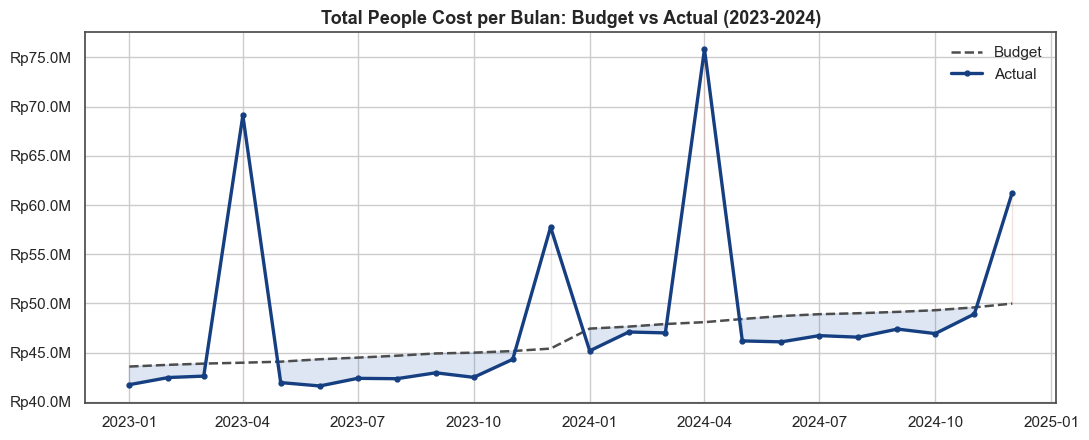

In [6]:
monthly = df.groupby("Date")[["Budget_IDR","Actual_IDR"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(monthly["Date"], monthly["Budget_IDR"], color=GREY, linestyle="--", linewidth=1.8, label="Budget")
ax.plot(monthly["Date"], monthly["Actual_IDR"], color=TEAL, linewidth=2.4, marker="o", markersize=3.5, label="Actual")
ax.fill_between(monthly["Date"], monthly["Budget_IDR"], monthly["Actual_IDR"],
                 where=(monthly["Actual_IDR"]>monthly["Budget_IDR"]), color=RED, alpha=0.15)
ax.fill_between(monthly["Date"], monthly["Budget_IDR"], monthly["Actual_IDR"],
                 where=(monthly["Actual_IDR"]<=monthly["Budget_IDR"]), color=TEAL_L, alpha=0.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(rp))
ax.set_title("Total People Cost per Bulan: Budget vs Actual (2023-2024)")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("chart_01_trend_budget_actual.png", dpi=150)
plt.show()


> 💡 **Key Business Insight & Strategic Action:**
> * **Pola Musiman (*Seasonality Patterns*):** Terdapat lonjakan signifikan pengeluaran *Actual* yang melampaui *Budget* secara berulang pada dua periode kunci:
>   1. **Maret–April (Periode THR & Persiapan Lebaran):** Terjadi pemenuhan kewajiban Tunjangan Hari Raya (THR) serta potensi lonjakan insentif/pembayaran *overtime* operasional.
>   2. **November–Desember (Kampanye Akhir Tahun):** Didorong oleh penyesuaian insentif performa serta lonjakan biaya tenaga kerja pendukung operasional akhir tahun.
> * ***Actionable Recommendation*:** : Lonjakan biaya di Q1/Q2 (THR) dan Q4 (akhir tahun) adalah pola tahunan yang pasti terjadi. Penganggaran periode berikutnya harus menyesuaikan kenaikan biaya di bulan-bulan tersebut agar tidak terjadi under-budgeting.

## 4. Breakdown Komposisi Biaya per Kategori

Analisis donut chart di bawah melihat porsi kontribusi dari setiap komponen *People Cost* terhadap total pengeluaran perusahaan selama periode 2023–2024.

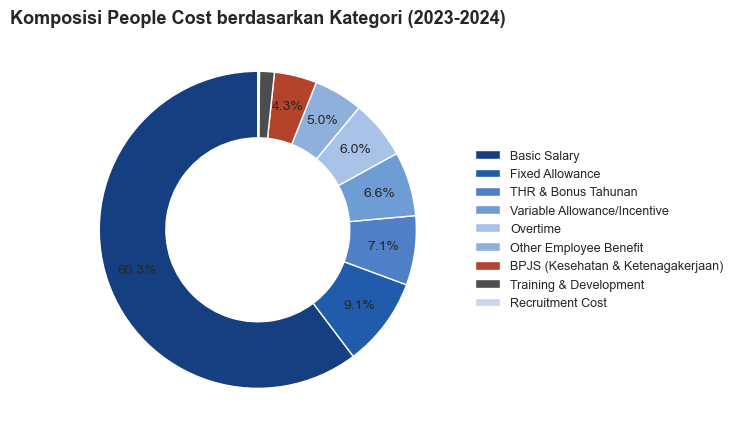

,Share (%)
Category,
Basic Salary,60
Fixed Allowance,9
THR & Bonus Tahunan,7
Variable Allowance/Incentive,7
Overtime,6
Other Employee Benefit,5
BPJS (Kesehatan & Ketenagakerjaan),4
Training & Development,2
Recruitment Cost,0


In [7]:
cat_comp = df.groupby("Category")["Actual_IDR"].sum().sort_values(ascending=False)
cat_share = (cat_comp / cat_comp.sum() * 100).round(1)

colors_cat = [TEAL, TEAL_L, GOLD, "#6E9DD6", "#A9C3E8",
              "#8FB0DC", RED, GREY, "#C7D6ED"]

fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(cat_comp, labels=None, autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
                                    colors=colors_cat, startangle=90, pctdistance=0.8,
                                    wedgeprops=dict(width=0.42, edgecolor="white"))
ax.set_title("Komposisi People Cost berdasarkan Kategori (2023-2024)")
ax.legend(wedges, cat_comp.index, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("chart_02_cost_composition.png", dpi=150)
plt.show()

cat_share.to_frame("Share (%)")


**Insight:** Basic Salary tetap menjadi komponen dominan (±60-65%), namun kategori yang paling *volatile* dan paling sering menyebabkan variance adalah **Overtime**, **Variable Allowance/Incentive**, dan **Recruitment Cost** — tiga kategori inilah yang paling penting untuk dimonitor lebih ketat di dashboard.

> 💡 **Key Insights & Takeaways:**
> * **Fixed Cost Dominan:** *Basic Salary* memakan porsi terbesar (~60%), disusul oleh *Fixed Allowance* (~9%). Komponen biaya tetap ini relatif stabil dan mudah diprediksi.
> * **Area Volatil yang Perlu Diawasi:** Walau porsinya lebih kecil, kategori seperti *Overtime*, *Variable Allowance/Incentive*, dan *Recruitment Cost* punya tingkat volatilitas paling tinggi.
> * **Fokus Monitoring:** Ketiga kategori variabel ini merupakan pemicu utama variansi anggaran (budget variance). Oleh karena itu, komponen tersebut memerlukan indikator pemantauan khusus di dashboard agar dapat diawasi secara berkala di tingkat divisi

## 5. Budget vs. Actual Variance Heatmap Across Divisions & Categories

Matriks *heatmap* di bawah berfungsi sebagai *diagnostic tool* untuk memetakan persentase deviasi (*variance %*) antara pengeluaran aktual dan anggaran di setiap kombinasi divisi dan kategori biaya. Warna merah yang semakin pekat mengindikasikan tingkat *over-budget* yang lebih tinggi.

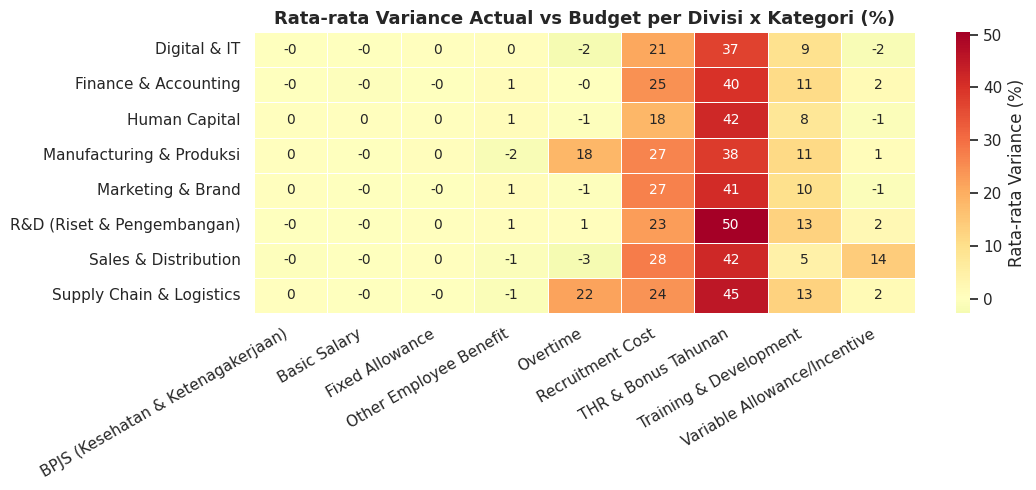

In [7]:
pivot_var = df.pivot_table(index="Division", columns="Category", values="Variance_Pct", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11,5))
sns.heatmap(pivot_var, annot=True, fmt=".0f", cmap="RdYlGn_r", center=0,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Rata-rata Variance (%)"}, ax=ax)
ax.set_title("Rata-rata Variance Actual vs Budget per Divisi x Kategori (%)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("chart_03_variance_heatmap.png", dpi=150)
plt.show()


> 💡 **Key Diagnostic Insights & Strategic Focus:**
> * **Pos Biaya Musiman (THR & Bonus):** Kategori *THR & Bonus Tahunan* menunjukkan deviasi merah pekat secara merata di seluruh divisi (37%–50%). Hal ini mengonfirmasi bahwa alokasi anggaran THR/Bonus belum sepenuhnya mencakup *baseline* pengeluaran realisasi.
> * **Hotspot Biaya Operasional (*Overtime*):** Pembengkakan *Overtime* terkonsentrasi pada divisi operasional, terutama **Supply Chain & Logistics (22%)** dan **Manufacturing & Produksi (18%)**, menandakan tingginya dinamika jam kerja di area lapangan.
> * **Tantangan Rekrutmen & Pengembangan Talent:** Biaya *Recruitment Cost* dan *Training & Development* menunjukkan *variance* positif di hampir seluruh divisi (21%–28% dan 5%–13%), dengan **R&D** serta **Sales & Distribution** mengalami lonjakan tertinggi pada biaya rekrutmen.
> * **Rekomendasi Tindakan:** Tim HR Analytics perlu memprioritaskan re-alokasi *budgeting* pada tiga pos utama ini (*THR, Overtime Operasional,* dan *Recruitment*) agar proyeksi anggaran di siklus berikutnya jauh lebih akurat.

## 6. Deep-Dive Analysis #1: Overtime Seasonality (Peak Demand Period)

Bagian ini menganalisis pola biaya lembur (*overtime*) pada dua divisi operasional utama—**Manufacturing & Produksi** serta **Supply Chain & Logistics**. Area merah pada grafik menyoroti window waktu 2 bulan menjelang Hari Raya Lebaran (Ramadan & persiapan pemenuhan stok).

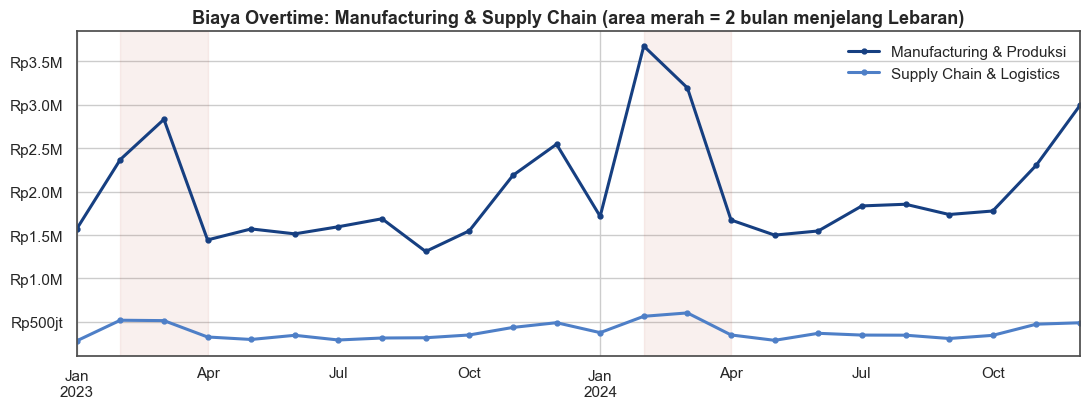

In [9]:
ot = df[(df["Category"]=="Overtime") & (df["Division"].isin(["Manufacturing & Produksi","Supply Chain & Logistics"]))]
ot_monthly = ot.groupby(["Date","Division"])["Actual_IDR"].sum().unstack()

fig, ax = plt.subplots(figsize=(11,4.2))
ot_monthly.plot(ax=ax, color=[TEAL, GOLD], linewidth=2.2, marker="o", markersize=3.5)
for yr in [2023, 2024]:
    lebaran_date = pd.Timestamp(f"{yr}-04-01")
    ax.axvspan(lebaran_date - pd.DateOffset(months=2), lebaran_date, color=RED, alpha=0.08)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(rp))
ax.set_title("Biaya Overtime: Manufacturing & Supply Chain (area merah = 2 bulan menjelang Lebaran)")
ax.set_xlabel(""); ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("chart_04_overtime_seasonality.png", dpi=150)
plt.show()


> 💡 **Key Diagnostic Findings & Recommendation:**
> * **Pola Musiman Lemak (*Operational Spike*):** Divisi Manufacturing & Produksi mengalami lonjakan biaya lembur yang sangat tajam menjelang periode Lebaran (mencapai puncak di Rp2.8M pada 2023 dan Rp3.6M pada 2024). Divisi Supply Chain & Logistics menunjukkan tren kenaikan yang sejalan, meski dengan skala nominal yang lebih moderat.
> * **Root Cause:** Lonjakan biaya lembur ini didorong oleh peningkatkan volume produksi dan distribusi untuk mengantisipasi tingginya permintaan pasar *fast-moving consumer goods* selama musim raya.
> * **Rekomendasi Anggaran (*Budget Buffer*):** Dibandingkan mengalokasikan anggaran lembur secara rata (*flat monthly budget*) sepanjang tahun, tim keuangan dan HR perlu menerapkan **seasonal overtime budget buffer** pada periode Februari–Maret (H-2 Lebaran) untuk mencegah terjadinya *negative variance* yang berulang setiap siklus tahunan.

## 7. Deep-Dive Analysis #2: Variable Incentive & E-Commerce Campaign Spikes

Bagian ini mengevaluasi dinamika pengeluaran *Variable Allowance & Incentive* pada divisi **Sales & Distribution**. Analisis ini berfokus pada hubungan antara lonjakan kompensasi variabel dengan momentum periode kampanye komersial utama (seperti mega sales 9.9, 11.11, dan Harbolnas/12.12).

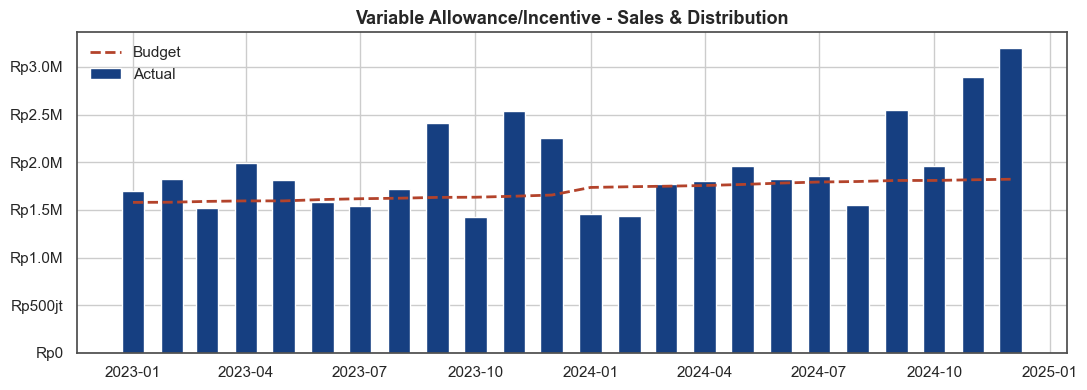

In [10]:
vi = df[(df["Category"]=="Variable Allowance/Incentive") & (df["Division"]=="Sales & Distribution")]
vi_m = vi.groupby("Date")[["Budget_IDR","Actual_IDR"]].sum()

fig, ax = plt.subplots(figsize=(11,4))
ax.bar(vi_m.index, vi_m["Actual_IDR"], width=18, color=TEAL, label="Actual")
ax.plot(vi_m.index, vi_m["Budget_IDR"], color=RED, linewidth=2, linestyle="--", label="Budget")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(rp))
ax.set_title("Variable Allowance/Incentive - Sales & Distribution")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("chart_05_sales_incentive.png", dpi=150)
plt.show()


> 💡 **Key Business Insights & Governance Strategy:**
> * **Korelasi Musim Kampanye (*Commercial Spikes*):** Realisasi insentif melampaui anggaran secara signifikan pada Q4 (September, November, dan Desember). Pembengkakan ini sejalan dengan peningkatan target pencapaian volume penjualan selama momentum kampanye *e-commerce* nasional.
> * **Kategori *Good Variance*:** Kenaikan biaya ini dikategorikan sebagai *good variance*, di mana pembengkakan pengeluaran berbanding lurus dengan peningkatan performa atau pendapatan (*revenue generation*), sehingga bukan merupakan indikasi pemborosan operasional.
> * **Rekomendasi Kebijakan Anggaran (*Budget Governance*):** Dashboard perlu dilengkapi dengan indikator pemisah antara *good variance* (linear terhadap *revenue/performance*) dan *bad variance* (ketidakefisienan operasional). Hal ini penting untuk mencegah tim manajemen mengambil keputusan efisiensi (*budget cut*) yang salah sasaran pada pos insentif penunjang target penjualan.

## 8. Deep-Dive Analysis #3: Strategic Talent Investment (Digital & IT Headcount vs. Recruitment Cost)

Bagian ini menguji korelasi antara dinamika pertumbuhan jumlah karyawan (*headcount index*) dengan pengeluaran rekrutmen (*recruitment cost*). Analisis ini menyoroti akselerasi investasi talenta pada divisi **Digital & IT** sebagai pendorong transformasi digital perusahaan.

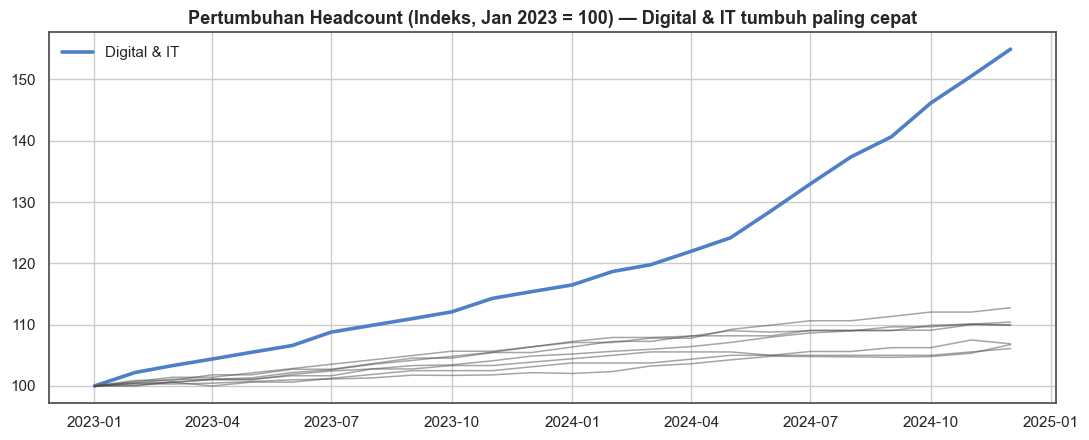


Total Recruitment Cost per Divisi (2023-2024):
Division
Digital & IT                  Rp857jt
Manufacturing & Produksi      Rp330jt
Sales & Distribution          Rp323jt
R&D (Riset & Pengembangan)    Rp135jt
Supply Chain & Logistics      Rp128jt
Marketing & Brand              Rp87jt
Human Capital                  Rp53jt
Finance & Accounting           Rp40jt
Name: Actual_IDR, dtype: object


In [11]:
hc = df.groupby(["Date","Division"])["Headcount"].mean().unstack()
hc_norm = hc / hc.iloc[0] * 100  # index ke 100 di bulan awal

fig, ax = plt.subplots(figsize=(11,4.5))
for d in hc_norm.columns:
    style = dict(linewidth=2.6, color=GOLD) if d == "Digital & IT" else dict(linewidth=1.1, color=GREY, alpha=0.5)
    ax.plot(hc_norm.index, hc_norm[d], label=d if d=="Digital & IT" else None, **style)
ax.set_title("Pertumbuhan Headcount (Indeks, Jan 2023 = 100) — Digital & IT tumbuh paling cepat")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("chart_06_headcount_growth.png", dpi=150)
plt.show()

rc = df[df["Category"]=="Recruitment Cost"].groupby("Division")["Actual_IDR"].sum().sort_values(ascending=False)
print("\nTotal Recruitment Cost per Divisi (2023-2024):")
print(rc.apply(rp))


> 💡 **Key Strategic Insights & Executive Takeaways:**
> * **Laju Pertumbuhan Headcount Tercepat (*Outlier Growth*):** Divisi **Digital & IT** mencatatkan laju pertumbuhan *headcount* paling agresif dibandingkan divisi lain (mencapai indeks >150 pada akhir 2024 dari *baseline* 100 di Jan 2023). Hal ini mencerminkan fokus ekspansi kapabilitas teknologis perusahaan.
> * **Alokasi Biaya Rekrutmen Dominan:** Divisi Digital & IT menyerap akumulasi biaya rekrutmen tertinggi (Rp857 juta)—hampir 2.5x lipat dari divisi operasional terbesar seperti Manufacturing (Rp330 juta) dan Sales (Rp323 juta).
> * **Analisis Nilai Tambah (*Cost per Hire Context*):** Tingginya biaya akuisisi talenta teknologi dipengaruhi oleh spesialisasi peran (*specialized tech talent* seperti Data Engineers, Solution Architects, & Software Engineers) serta penggunaan saluran rekrutmen bernilai tinggi (*headhunter/specialized portals*).
> * **Rekomendasi Komunikasi Stakeholder:** Pengeluaran rekrutmen yang tinggi pada divisi teknis perlu diposisikan sebagai **strategic capability investment** jangka panjang, bukan sekadar beban operasional (*overhead cost*).

## 9. Cost Efficiency Analysis: Cost per Headcount Across Divisions

Bagian ini mengevaluasi rata-rata efisiensi pengeluaran *People Cost* per karyawan (*Cost per Headcount*) di setiap divisi pada posisi periode terbaru (Desember 2024). Metrik ini dihitung dengan membagi total realisasi biaya dengan rerata jumlah tenaga kerja aktif.

C:\Users\Dell\AppData\Local\Temp\ipykernel_14776\92880386.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cph = df.groupby(["Date","Division"]).apply(lambda x: x["Actual_IDR"].sum()/x["Headcount"].mean()).unstack()


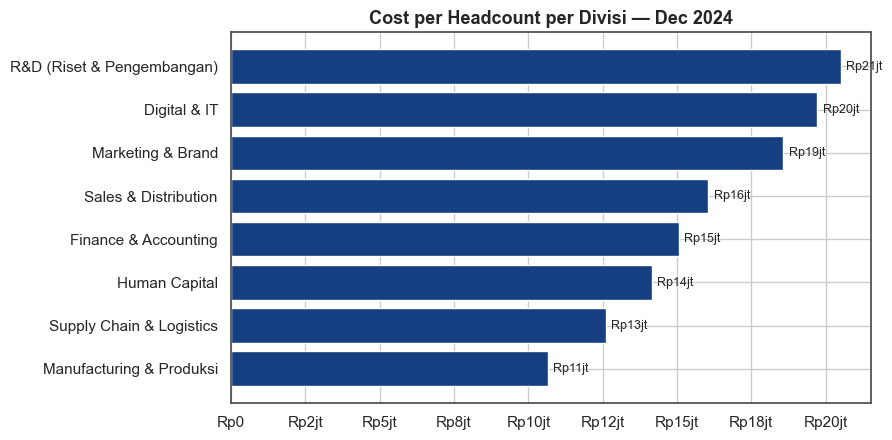

In [12]:
cph = df.groupby(["Date","Division"]).apply(lambda x: x["Actual_IDR"].sum()/x["Headcount"].mean()).unstack()
cph_last = cph.iloc[-1].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9,4.5))
bars = ax.barh(cph_last.index[::-1], cph_last.values[::-1], color=TEAL)
ax.bar_label(bars, labels=[rp(v) for v in cph_last.values[::-1]], padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(rp))
ax.set_title(f"Cost per Headcount per Divisi — {cph.index[-1].strftime('%b %Y')}")
plt.tight_layout()
plt.savefig("chart_07_cost_per_head.png", dpi=150)
plt.show()


> 💡 **Key Executive Insights & Strategic Benchmarking:**
> * **Struktur Biaya Spesialis (*High-Value Talent*):** Divisi **R&D (Rp21 juta/bln)** dan **Digital & IT (Rp20 juta/bln)** mencatatkan *cost per headcount* tertinggi. Hal ini menunjukkan profil kompensasi talenta dengan spesialisasi tinggi (*highly skilled technical personnel*).
> * **Efisiensi Skala Operasional (*Scale Efficiency*):** Divisi berbasis lapangan seperti **Manufacturing & Produksi (Rp11 juta/bln)** serta **Supply Chain (Rp13 juta/bln)** memiliki *cost per headcount* paling rendah, sejalan dengan tingginya proporsi tenaga kerja operasional.
> * **Aplikasi Strategis (*Internal Benchmarking*):** Indikator ini menjadi *baseline* penting untuk perencanaan struktur kompensasi, evaluasi batas alokasi anggaran penambahan *headcount* baru (*hiring budget limit*), serta pemantauan efisiensi struktur biaya di tiap divisi.

## 10. Short-Term Financial Projection: People Cost (3-Month Forward Look)

Bagian ini menyajikan estimasi pengeluaran *People Cost* untuk 3 bulan ke depan sebagai *baseline* perencanaan anggaran (*budgetary starting point*). Model ini menggabungkan tren pertumbuhan historis (*underlying trend*) dengan penyesuaian pola musiman (*seasonal adjustment factor*) dari siklus tahun sebelumnya.

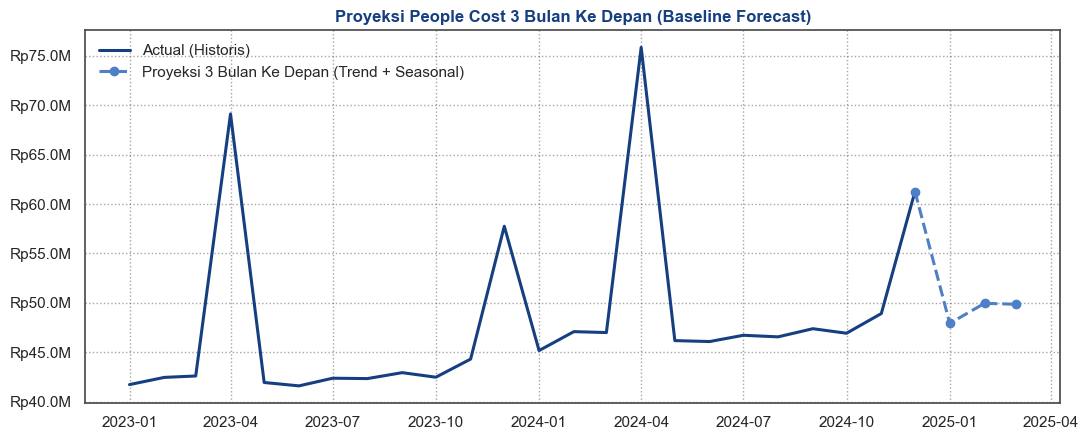

📌 Proyeksi People Cost 3 Bulan Ke Depan:
   • Jan 2025: Rp47.9M
   • Feb 2025: Rp50.0M
   • Mar 2025: Rp49.9M


In [17]:
# 1. Menyiapkan Data Time Series Historis
ts = monthly.set_index("Date")["Actual_IDR"]

# 2. Perhitungan Proyeksi (Trend + Seasonality Adjustment)
# Menghitung MoM growth rata-rata 6 bulan terakhir
monthly_diff = ts.pct_change().dropna()
recent_trend = ts.iloc[-1] * (1 + monthly_diff.tail(6).mean())

# Tanggal Proyeksi (3 Bulan Ke Depan: Jan, Feb, Mar 2025)
future_dates = pd.date_range(ts.index[-1] + pd.DateOffset(months=1), periods=3, freq="MS")

# Faktor Musim (Menyesuaikan dengan dinamika bulan yang sama tahun sebelumnya)
same_months_last_year = ts.loc[future_dates - pd.DateOffset(years=1)]
growth_rate = ts.iloc[-1] / ts.loc[ts.index[-1] - pd.DateOffset(years=1)]
forecast_values = same_months_last_year.values * growth_rate

forecast = pd.Series(forecast_values, index=future_dates)

plot_forecast = pd.concat([ts.tail(1), forecast])

# 3. Visualisasi Grafik Proyeksi
fig, ax = plt.subplots(figsize=(11, 4.5))

# Plot Data Historis (Warna Primary - Navy TEAL)
ax.plot(ts.index, ts.values, color=TEAL, linewidth=2.2, label="Actual (Historis)")

# Plot Proyeksi 3 Bulan (Warna Aksen GOLD / Light Blue dengan garis putus-putus)
ax.plot(
    plot_forecast.index, 
    plot_forecast.values, 
    color=GOLD, 
    linewidth=2.2, 
    linestyle="--", 
    marker="o", 
    label="Proyeksi 3 Bulan Ke Depan (Trend + Seasonal)"
)

# Style & Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(rp))
ax.set_title("Proyeksi People Cost 3 Bulan Ke Depan (Baseline Forecast)", fontsize=12, fontweight="bold", color=TEAL)
ax.legend(frameon=False, loc="upper left")
ax.grid(True, linestyle=":", alpha=0.5, color=GREY)

plt.tight_layout()
plt.savefig("chart_08_forecast.png", dpi=150)
plt.show()

# Print Output Ringkasan
print("📌 Proyeksi People Cost 3 Bulan Ke Depan:")
for d, v in forecast.items():
    print(f"   • {d.strftime('%b %Y')}: {rp(v)}")

> 💡 **Executive Summary & Forecasting Context:**
> * **Proyeksi Dinamis (*Seasonal Trend*):** Mengatasi keterbatasan *linear trend* kaku yang cenderung datar, model ini memasukkan faktor *seasonality*. Penyesuaian ini mengantisipasi lonjakan bertahap menjelang awal kuartal pertama seiring dengan persiapan periode puncak operasional.
> * **Fungsi Anggaran (*Baseline vs Operational Plan*):** Angka proyeksi ini berfungsi sebagai *baseline* diskusi untuk penambahan *headcount* (*hiring expansion*) maupun alokasi anggaran THR/bonus tahun berjalan.
> * **Rekomendasi Penyesuaian Model (*Model Calibration*):** Untuk penerapan level produksi (*production-grade forecasting*), model perlu diintegrasikan secara langsung dengan data rencana rekrutmen (*final hiring plan*), jadwal pembayaran kompensasi variabel, serta revisi target bisnis tiap divisi.

## 11. Executive Summary & Strategic Recommendations

Bagian ini merangkum temuan kunci (*key diagnostic findings*) dari analisis pengeluaran tenaga kerja (*People Cost*) beserta rekomendasi tindakan strategis dan roadmap pengembangan sistem analitik ke depan.

### 📊 Summary Table: Insights & Strategic Actions

| # | Key Analytical Insight | Strategic Recommendation | Strategic Outcome / Business Impact |
|---|------------------------|--------------------------|--------------------------------------|
| **1** | **Overtime Seasonality Spikes**<br>Biaya lembur Manufacturing & Supply Chain melonjak signifikan H-2 bulan menjelang Hari Raya Lebaran. | Menerapkan *seasonal budget buffer* pada periode puncak (Feb–Mar), menggantikan alokasi *flat budget* bulanan. | Mencegah *negative variance* berulang dan meningkatkan akurasi *cash flow forecasting*. |
| **2** | **Commercial Incentive Expansion**<br>Realisasi *variable incentive* Sales melampaui anggaran selama periode mega sales e-commerce (9.9, 11.11, 12.12). | Mengklasifikasikan pembengkakan ini sebagai **"Good Variance"** (linear terhadap pencapaian *revenue*). | Mencegah keputusan *budget cut* yang salah sasaran pada elemen penunjang target penjualan. |
| **3** | **Strategic Tech Talent Investment**<br>Divisi Digital & IT mencatatkan pertumbuhan *headcount* dan *recruitment cost per hire* tertinggi. | Memposisikan pengeluaran rekrutmen teknologi sebagai **strategic capability investment** jangka panjang. | Menjaga transparansi efisiensi anggaran tanpa menghentikan akselerasi transformasi digital. |
| **4** | **Fixed vs Volatile Cost Structure**<br>Komponen *Basic Salary & Fixed Allowance* mendominasi ±65–70% dari total pengeluaran. | Memfokuskan pengawasan bulanan (*monthly tracking*) pada 3 kualifikasi biaya volatil: *Overtime, Variable Incentive,* dan *Recruitment*. | Optimalisasi waktu dan fokus manajemen keuangan (*high-leverage monitoring*). |
| **5** | **Cost per Headcount Disparities**<br>Metrik *cost per headcount* bervariasi signifikan antar divisi sesuai tingkat spesialisasi peran. | Menggunakan metrik ini sebagai *internal benchmark* saat penetapan *hiring budget limit* dan evaluasi kompensasi tahunan. | Menjaga efisiensi struktur biaya penggajian tanpa mengabaikan *market rate* posisi spesialis. |

---

### 🚀 Production Dashboard Roadmap & Next Steps

Untuk mentransformasi analisis ini menjadi solusi analitik tingkat produksi (*enterprise-grade analytics system*), langkah-langkah berikut direkomendasikan untuk fase implementasi selanjutnya:

* 🔗 **Live System Integration:** Mengintegrasikan *pipeline* data secara otomatis ke sistem sumber riil (*Payroll System* untuk kompensasi, *Applicant Tracking System/ATS* untuk biaya rekrutmen, dan *Absensi/Time-tracking* untuk *overtime*).
* 🔍 **Granular Drill-Through Capabilities:** Menyediakan fitur *drill-through* hingga ke level sub-divisi, *cost center*, serta pengelompokan tingkat jabatan (*job level*).
* 🚨 **Automated Anomaly Detection & Threshold Alerts:** Mengkonfigurasi peringatan otomatis (*automated flag*) saat terjadi deviasi anggaran secara real-time (misalnya: *red flag* muncul jika *actual variance* > 15% dari *budget limit*).